In [65]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import h5py
import re

In [66]:
# ========= 1. 設定 (Configuration) =========

base_dir = r"C:\experiment\1D"

# 每個 group 可以包含多個檔案（合算後一起計算統計量）
# CSV 已不再使用，skip 資訊直接從 H5 的 skip_events 讀取
experiments = [
    {"group_val":  5, "group": "5cm", "files": [
        {"h5": os.path.join(base_dir, "t0103", "t0103.h5")},
    ]},
    {"group_val":  7, "group": "7cm", "files": [
        {"h5": os.path.join(base_dir, "t0104", "t0104.h5")},
    ]},
    {"group_val": 10, "group": "10cm", "files": [
        {"h5": os.path.join(base_dir, "t0105", "t0105.h5")},
    ]},
    {"group_val": 12, "group": "12cm", "files": [
        {"h5": os.path.join(base_dir, "t0106", "t0106.h5")},
    ]},
    # t0100 和 t0107 都是 15cm，合算為同一組
    {"group_val": 15, "group": "15cm", "files": [
        {"h5": os.path.join(base_dir, "t0100", "t0100.h5")},
        {"h5": os.path.join(base_dir, "t0107", "t0107.h5")},
    ]},
]

# 限制 X 軸 (Normal Stress) 範圍
xlim_min = 6
xlim_max = 34

In [67]:
# ========= 2. 資料處理 (Data Processing) =========

def extract_sigma(run_name):
    # 從 run1_32MPa 這樣的字串中提取 32 這個數值
    match = re.search(r'_(\d+)MPa', str(run_name))
    if match:
        return float(match.group(1))
    return np.nan

def get_run_index(run_str):
    match = re.search(r'run(\d+)', str(run_str))
    return int(match.group(1)) if match else None

def _read_skip_events(run_group):
    # 從 H5 的 run group 中讀取 skip_events 清單（event index 列表，1-based）。
    #
    # 儲存路徑優先順序：
    #   1. runs/{run_idx}/config/skip_events  （新版 labquake_explorer 寫入位置）
    #   2. runs/{run_idx}/skip_events          （舊版 legacy 路徑，向後相容）
    import h5py as _h5py

    def _parse_se(se_obj):
        if isinstance(se_obj, _h5py.Group):
            return [int(se_obj[k][()]) for k in sorted(se_obj.keys(), key=int)]
        else:
            raw = se_obj[()]
            if hasattr(raw, 'tolist'):
                result = raw.tolist()
                # numpy 0-D scalar 的 tolist() 回傳 Python int，而非 list，需強制包裝
                return result if isinstance(result, list) else [result]
            else:
                return list(raw)

    # 優先讀取新路徑
    if 'config' in run_group and 'skip_events' in run_group['config']:
        return _parse_se(run_group['config']['skip_events'])

    # 向後相容：舊路徑
    if 'skip_events' in run_group:
        return _parse_se(run_group['skip_events'])

    return []

def extract_max_sliprate_from_h5(h5_path, run_index):
    # 讀取 HDF5 特定 run_index 的 max slip rate。
    # 只取中間 sensor (ch13) 的 max slip rate。
    # 位移單位為 μm，故 slip rate 單位為 μm/s。
    #
    # skip 機制：
    #   skip_events 中的事件編號 N (1-based) 對應高頻區塊 Block N+1
    #   （Block 1 為背景連續資料，不受 skip 影響）
    #   被 skip 的區塊將從極值計算中完全排除，避免儀器雜訊干擾最終結果。
    if not os.path.exists(h5_path):
        return np.nan

    try:
        with h5py.File(h5_path, 'r') as f:
            run_idx_str = str(int(run_index) - 1)  # run1 -> 0
            if "runs" not in f or run_idx_str not in f["runs"]:
                return np.nan

            run_group = f["runs"][run_idx_str]
            th_group = run_group["time history"]

            # 讀取 skip_events，轉換為應排除的高頻區塊編號集合
            # 事件 N (1-based) 的高頻紀錄儲存於 Block N+1
            skipped_events = _read_skip_events(run_group)
            skipped_blocks = {int(ev) + 1 for ev in skipped_events}

            # 只取中間 sensor (ch13)
            ch = 13

            # 背景連續區塊（Block 1）的最大滑移速率，不受 skip 影響
            bg_max = 0
            if f'sliprate_ch{ch}' in th_group:
                rate_data = th_group[f'sliprate_ch{ch}'][:]
                if len(rate_data) > 0:
                    bg_max = np.max(rate_data)

            # 高頻觸發區塊：排除被 skip 的事件對應區塊
            hr_max = 0
            if "high_rate_sliprates" in th_group:
                hr_group = th_group["high_rate_sliprates"]
                hr_keys = [k for k in hr_group.keys() if f'high_sliprate_ch{ch}_blk' in k]
                hr_max_list = []
                for k in hr_keys:
                    # 從 key 名稱解析區塊編號，例如 high_sliprate_ch13_blk4 -> 4
                    blk_match = re.search(r'_blk(\d+)$', k)
                    if blk_match and int(blk_match.group(1)) in skipped_blocks:
                        continue  # 跳過被 skip 的事件對應區塊
                    data = hr_group[k][:]
                    if len(data) > 0:
                        hr_max_list.append(np.max(data))
                if hr_max_list:
                    hr_max = max(hr_max_list)

            return max(bg_max, hr_max)
    except Exception as e:
        print(f"讀取 {h5_path} run {run_index} 發生錯誤: {e}")
        return np.nan

def process_max_sliprate_data():
    # 直接從 H5 讀取 run 清單與 skip_events，不再依賴 CSV。
    # skip 判斷邏輯：若一個 run 中所有 events 均已被 skip，則略過該 run。
    # 同一 group 下多個檔案會合併後一起計算統計量。
    processed_data = []
    for exp in experiments:
        group_df_list = []

        for finfo in exp['files']:
            h5_path = finfo['h5']
            if not os.path.exists(h5_path):
                print(f"找不到 H5 檔案: {h5_path}，略過")
                continue

            records = []
            with h5py.File(h5_path, 'r') as f:
                if 'runs' not in f:
                    continue
                runs_group = f['runs']

                for run_key in sorted(runs_group.keys(), key=lambda x: int(x)):
                    run = runs_group[run_key]

                    # 讀取 run 名稱
                    if 'name' not in run:
                        continue
                    run_name = run['name'][()].decode()

                    # 解析 sigma 與 run_index
                    sigma = extract_sigma(run_name)
                    run_index = get_run_index(run_name)
                    if np.isnan(sigma) or run_index is None:
                        continue

                    # 讀取 skip_events（直接從 H5，不靠 CSV）
                    skipped_events = _read_skip_events(run)

                    # 計算有效事件數
                    total_events = 0
                    if 'events' in run:
                        total_events = len([
                            k for k in run['events'].keys()
                            if k.isdigit() and int(k) > 0
                        ])

                    # 若所有事件都被 skip，略過此 run
                    if total_events > 0 and len(skipped_events) >= total_events:
                        print(f"  [{run_name}] 所有事件均已 skip，略過")
                        continue

                    records.append({
                        'Run': run_name,
                        'sigma': sigma,
                        'run_index': run_index
                    })

            if not records:
                continue

            df = pd.DataFrame(records)
            df['max_sliprate'] = df['run_index'].apply(
                lambda idx: extract_max_sliprate_from_h5(h5_path, idx)
            )
            group_df_list.append(df)

        if not group_df_list:
            continue

        # 合併同一 group 所有檔案
        combined_df = pd.concat(group_df_list, ignore_index=True)
        combined_df = combined_df.dropna(subset=['sigma', 'max_sliprate'])

        # 計算每個 sigma 的統計量
        stats = combined_df.groupby('sigma')['max_sliprate'].agg(
            median='median',
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75)
        ).reset_index()

        processed_data.append({
            'group': exp['group'],
            'group_val': exp['group_val'],
            'stats': stats
        })
    return processed_data

In [68]:
custom_colors = ['#F4A63A', '#A2C4F1', '#A5D1B0', '#DF562C', '#CEBAF0', '#E8D2B3', '#015493']

In [69]:
# ========= 3. 繪圖函式 (Plotting Function) =========

def plot_max_sliprate_by_sigma(title="Max Slip Rate Comparison", ylabel=r"Max Slip Rate [$\mu$m/s]"):
    """以 sigma 為 X 軸繪圖，不同 group 各一條序列。"""
    data_to_plot = process_max_sliprate_data()

    if not data_to_plot:
        print(f"沒有可供繪圖的資料")
        return

    # colormap：以 group_val 排序對應 custom_colors
    group_vals = [item['group_val'] for item in data_to_plot]
    n = len(group_vals)
    colors = custom_colors[:n]
    val_to_idx = {v: i for i, v in enumerate(group_vals)}

    # 建立 colorbar 用的 ScalarMappable
    from matplotlib.colors import ListedColormap, BoundaryNorm
    cmap_cb = ListedColormap(colors)
    bounds = [i - 0.5 for i in range(n)] + [n - 0.5]
    norm_cb = BoundaryNorm(bounds, cmap_cb.N)
    sm = plt.cm.ScalarMappable(cmap=cmap_cb, norm=norm_cb)
    sm.set_array([])

    fig, ax = plt.subplots(figsize=(8, 5))

    all_sigmas = []
    texts_to_draw = []
    for item in data_to_plot:
        stats = item['stats']
        sigmas = stats['sigma'].values
        medians = stats['median'].values
        yerr_lower = medians - stats['q1'].values
        yerr_upper = stats['q3'].values - medians
        color = colors[val_to_idx[item['group_val']]]

        all_sigmas.extend(sigmas)

        ax.errorbar(
            sigmas, medians,
            yerr=[yerr_lower, yerr_upper],
            fmt='s', color=color,
            markersize=8, capsize=5,
            markeredgewidth=1, markeredgecolor='gray',
            elinewidth=1.2, alpha=0.8, zorder=3
        )

        # 趨勢線
        if len(sigmas) > 1:
            slope, intercept = np.polyfit(sigmas, medians, 1)
            x_line = np.array([sigmas.min(), sigmas.max()])
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color=color, linestyle='--', linewidth=1.5, alpha=0.6, zorder=2)
            texts_to_draw.append({
                'x': x_line[-1] + 0.5,
                'y': y_line[-1],
                'text': f' m={slope:.3g}',
                'color': color
            })

    ax.set_xlabel(r'Normal Stress $\sigma$ [MPa]', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(axis='y', alpha=0.6)
    ax.set_xlim(xlim_min, xlim_max)

    if all_sigmas:
        ax.set_xticks(np.unique(all_sigmas))

    # Y 軸科學記號
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)

    # colorbar 取代圖例
    cbar = fig.colorbar(sm, ax=ax, ticks=list(range(n)), aspect=30)
    cbar.set_label('Seismogenic Zone Length', fontsize=12)
    cbar.ax.set_yticklabels([item['group'] for item in data_to_plot])
    plt.tight_layout()
    plt.show()

def plot_max_sliprate_by_group(title="Max Slip Rate Comparison", ylabel=r"Max Slip Rate [$\mu$m/s]"):
    """以群組為 X 軸（數值型），不同 sigma 各一條序列。"""
    group_order = [exp['group'] for exp in experiments]
    group_xval  = {exp['group']: exp['group_val'] for exp in experiments}

    data_to_plot = process_max_sliprate_data()

    if not data_to_plot:
        print(f"沒有可供繪圖的資料")
        return

    # 收集所有出現的 sigma
    all_sigmas_set = set()
    for item in data_to_plot:
        all_sigmas_set.update(item['stats']['sigma'].values)
    unique_sigmas = sorted(all_sigmas_set)

    # colormap：以 sigma 排序對應 custom_colors
    n = len(unique_sigmas)
    colors = custom_colors[:n]
    sigma_to_idx = {s: i for i, s in enumerate(unique_sigmas)}

    # 建立 colorbar 用的 ScalarMappable
    from matplotlib.colors import ListedColormap, BoundaryNorm
    cmap_cb = ListedColormap(colors)
    bounds = [i - 0.5 for i in range(n)] + [n - 0.5]
    norm_cb = BoundaryNorm(bounds, cmap_cb.N)
    sm = plt.cm.ScalarMappable(cmap=cmap_cb, norm=norm_cb)
    sm.set_array([])

    fig, ax = plt.subplots(figsize=(8, 5))
    texts_to_draw = []

    for sigma in unique_sigmas:
        x_vals, y_vals, yerr_lo, yerr_hi = [], [], [], []

        for item in data_to_plot:
            group = item['group']
            if group not in group_xval:
                continue
            stats = item['stats']
            row = stats[stats['sigma'] == sigma]
            if row.empty:
                continue
            x_vals.append(group_xval[group])
            med = row['median'].values[0]
            q1  = row['q1'].values[0]
            q3  = row['q3'].values[0]
            y_vals.append(med)
            yerr_lo.append(med - q1)
            yerr_hi.append(q3 - med)

        if not x_vals:
            continue

        x_arr = np.array(x_vals)
        y_arr = np.array(y_vals)
        color = colors[sigma_to_idx[sigma]]

        ax.errorbar(
            x_arr, y_arr,
            yerr=[np.array(yerr_lo), np.array(yerr_hi)],
            fmt='s', color=color,
            markersize=10, capsize=5,
            markeredgewidth=1, markeredgecolor='gray',
            elinewidth=1.2, alpha=1, zorder=3
        )

        # 趨勢線
        if len(x_arr) > 1:
            slope, intercept = np.polyfit(x_arr, y_arr, 1)
            x_line = np.array([x_arr.min(), x_arr.max()])
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color=color, linestyle='--', linewidth=1.5, alpha=0.6, zorder=2)
            texts_to_draw.append({
                'x': x_line[-1] + 0.1,
                'y': y_line[-1],
                'text': f' m={slope:.3g}',
                'color': color
            })

    ax.set_xlabel('Seismogenic Zone Length', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    x_vals_all = list(group_xval.values())
    ax.set_xlim(min(x_vals_all) - 1, max(x_vals_all) + 1)
    ax.set_xticks(x_vals_all)
    ax.set_xticklabels(group_order)
    ax.grid(axis='y', alpha=0.6)

    # Y 軸科學記號
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)

    # colorbar 取代圖例
    cbar = fig.colorbar(sm, ax=ax, ticks=list(range(n)), aspect=30)
    cbar.set_label(r'Normal Stress $\sigma$', fontsize=12)
    cbar.ax.set_yticklabels([f'{s:.0f} MPa' for s in unique_sigmas])
    plt.tight_layout()
    plt.show()

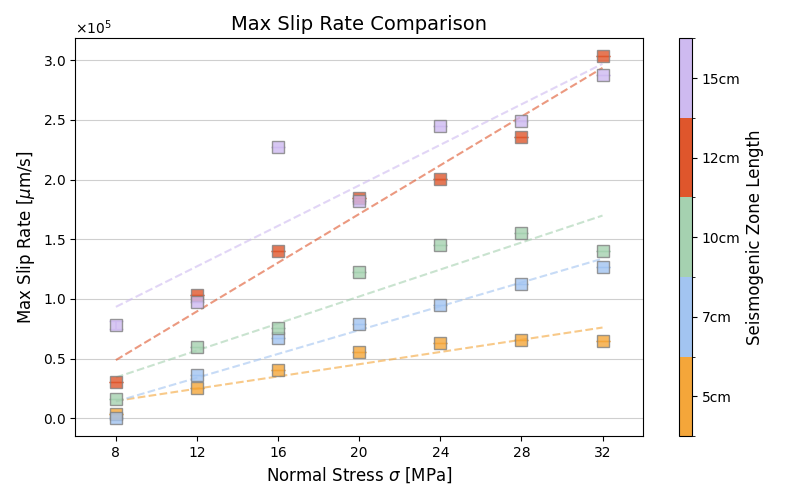

In [70]:
plot_max_sliprate_by_sigma()

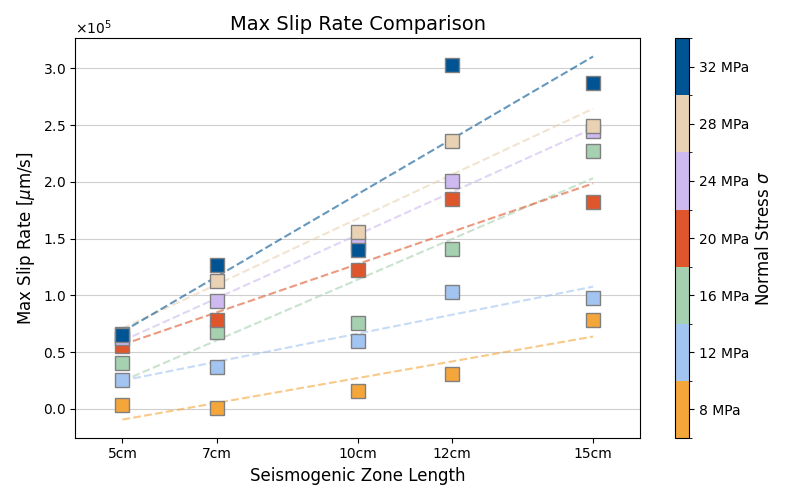

In [71]:
plot_max_sliprate_by_group()